In [349]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import  confusion_matrix
from sklearn.utils import resample


df_ml=pd.read_csv('Data/data.csv')
# Filter players with at least 5 or 10 appearances
df_ml = df_ml[df_ml['Appearances'] >= 10]


In [350]:
# 1. Cleaning and Preprocessing
cols_to_fix = ['Cross accuracy %', 'Shooting accuracy %', 'Tackle success %']

for col in cols_to_fix:
    if col in df_ml.columns:
        # Convert to string first to safely use .str, then remove %
        df_ml[col] = df_ml[col].astype(str).str.replace('%', '', regex=False)
        # Convert back to numeric, turning invalid strings into NaN
        df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

# List of all numerical features to fill with 0
numerical_cols = [
    'Goals per match', 'Headed goals', 'Goals with right foot', 
    'Goals with left foot', 'Penalties scored', 'Freekicks scored', 
    'Shots', 'Shots on target', 'Shooting accuracy %', 'Hit woodwork', 
    'Big chances missed', 'Clean sheets', 'Goals conceded', 'Tackles', 
    'Tackle success %', 'Offsides', 'Cross accuracy %', 'Assists',
    'Passes per match', 'Big chances created', 'Through balls', 
    'Interceptions', 'Recoveries'
]

# Fill missing numerical values with 0
df_ml[numerical_cols] = df_ml[numerical_cols].fillna(0)

# Drop rows with missing critical identity info
df_ml = df_ml.dropna(subset=['Nationality', 'Age', 'Jersey Number'])

# Handle duplicates
#print(f"Duplicate entries: {df_ml['Name'].duplicated().sum()}")

In [351]:
#classification for players 
forwards = df_ml[df_ml['Position'].str.contains('Forward')].copy()
midfielders = df_ml[df_ml['Position'].str.contains('Midfielder')].copy()
defenders = df_ml[df_ml['Position'].str.contains('Defender')].copy()
goalkeepers = df_ml[df_ml['Position'].str.contains('Goalkeeper')].copy()

In [352]:
# 2. Prepare Data for Modeling
# Define Top 6 clubs in 2020
clubs = ['Manchester City', 'Liverpool', 'Manchester United', 'Chelsea', 'Leicester City', 'Tottenham Hotspur']
def prepare_model_data(df, features, top_6_clubs):
    # Clean percentage columns if they exist in features
    for col in features:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = df[col].str.replace('%', '').astype(float) / 100
    
    # Create Target
    df['is_top_6'] = df['Club'].apply(lambda x: 1 if x in top_6_clubs else 0)
    
    # 2. X, y Split
    X = df[features]
    y = df['is_top_6']
    
    # 3. Data Splitting (Train/Test)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)# test_size=0.2: 20% of the data will be used for testing, and 80% for training. random_state=42: This is a common choice for reproducibility. It ensures that the same random split is generated each time you run the code.
    
    # Feature Scaling (Z-score Normalization : transforms features so they have a mean of 0 and a standard deviation of 1) 
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw) #The scaler calculates the mean (μ) and standard deviation (σ) for every column in your data. It "learns" the parameters.then it applies the transformation to the data, resulting in a new dataset where each feature has a mean of 0 and a standard deviation of 1.
    X_test = scaler.transform(X_test_raw) # Use 'transform' only for test data
    
    return X_train, X_test, y_train, y_test, scaler



In [353]:
#3.  Initialize and Fit Logistic Regression
def logistic_regression_pipeline(X_train, y_train, X_test, y_test):
    # This is equivalent to L2 but follows the new standard
    model = LogisticRegression(class_weight='balanced', C=1.0) #l1_ratio=0: Means 0% L1 and 100% L2 and applying "L2 Regularization" thet is a technique used to solve the problem of Overfitting (High Variance),C=1.0: This is the default value and means no regularization. A smaller C value (e.g., 0.1) would increase regularization, while a larger C value (e.g., 10) would decrease it.
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # confusion matrix and accuracy
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"""    True Positives (TP): Players correctly classified as being in top clubs.
    False Positives (FP): Players incorrectly classified as being in top clubs.
    False Negatives (FN): Players incorrectly classified as not being in top clubs.
    True Negatives (TN): Players correctly classified as not being in top clubs.""")
    return model



In [354]:
#4. Initialize and Fit GDA (LDA)
def GDA(X_train, X_test, y_train, y_test, features):
    # 1. Initialize and Fit GDA (LDA)
    # GDA is a generative model: it learns P(x|y) and P(y)
    model = LinearDiscriminantAnalysis()
    model.fit(X_train, y_train)
    y_pred =model.predict(X_test)
    
   # Confusion matrix and accuracy (Same style as your Logistic code)
    print(f"Test Accuracy (GDA): {accuracy_score(y_test, y_pred):.2f}")
    print("Confusion Matrix (GDA):")
    print(confusion_matrix(y_test, y_pred))
            
    return model

In [355]:

def plot_decision_boundaries(X, y, model_lr, model_gda, features):
    # We can only plot in 2D, so we take the first two features
    # X should be scaled data (X_test or X_train)
    X_plot = X[:, :2]
    
    # Create a mesh grid to plot the decision boundaries
    x_min, x_max = -1.5,2.0
    y_min, y_max = -2.5,2.0
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    plt.figure(figsize=(10, 6))

    # --- Plotting Logistic Regression Boundary ---
    # We need to retrain on only 2 features for the plot to work
    model_lr_2d = LogisticRegression(class_weight='balanced', C=1.0).fit(X_plot, y)
    Z_lr = model_lr_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_lr = Z_lr.reshape(xx.shape)
    plt.contour(xx, yy, Z_lr, colors='blue', levels=[0.5], alpha=0.8)
    
    # --- Plotting GDA (LDA) Boundary ---
    tmp_gda = LinearDiscriminantAnalysis(priors=[0.5, 0.5]).fit(X_plot, y)
    Z_gda = tmp_gda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contour(xx, yy, Z_gda, colors='red', levels=[0.5], alpha=0.8, linestyles='--')
    # --- Plotting the Data Points ---
    plt.scatter(X_plot[y == 0, 0], X_plot[y == 0, 1], c='gray', alpha=0.5, label='Not Top 6')
    plt.scatter(X_plot[y == 1, 0], X_plot[y == 1, 1], c='gold', edgecolors='black', label='Top 6')
    # Customizing the Plot
    plt.title(f'Decision Boundaries: Blue (Logistic) vs Red/Dashed (GDA)')
    plt.xlabel(features[0])
    plt.ylabel(features[1])
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# How to use it:
 

In [356]:
#prediction function
def predict_player_status(player_name, position_df, features, model_log, model_gda, scaler):
    # 1. Get player data from the dataframe
    player_data = position_df[position_df['Name'] == player_name]
    
    if player_data.empty:
        return f"Player '{player_name}' not found in this category."
    
    # 2. Extract features and Scale them
    X_raw = player_data[features]
    X_scaled = scaler.transform(X_raw)
    
    # 3. Get Predictions (0 or 1)
    pred_log = model_log.predict(X_scaled)[0]
    pred_gda = model_gda.predict(X_scaled)[0]
    
    # 4. Get Probabilities (Optional but cool to see)
    prob_log = model_log.predict_proba(X_scaled)[0][1] * 100
    
    # Formatting the output
    status_log = "Deserves Top 6" if pred_log == 1 else "Does NOT deserve Top 6"
    status_gda = "Deserves Top 6" if pred_gda == 1 else "Does NOT deserve Top 6"
    
    result = f"""
Prediction Report for: {player_name}
{'-'*35}
Logistic Regression : {status_log} (Confidence: {prob_log:.1f}%)
GDA Model           : {status_gda}
{'-'*35}
"""
    return result


#cap the features 
forwards['Goals per match'] = forwards['Goals per match'].clip(upper=1.2)
forwards['Shooting accuracy %'] = forwards['Shooting accuracy %'].clip(upper=80)
midfielders['Passes per match'] = midfielders['Passes per match'].clip(upper=90)


Test Accuracy: 0.69
Confusion Matrix:
[[29 13]
 [ 1  2]]
    True Positives (TP): Players correctly classified as being in top clubs.
    False Positives (FP): Players incorrectly classified as being in top clubs.
    False Negatives (FN): Players incorrectly classified as not being in top clubs.
    True Negatives (TN): Players correctly classified as not being in top clubs.
Test Accuracy (GDA): 0.84
Confusion Matrix (GDA):
[[38  4]
 [ 3  0]]


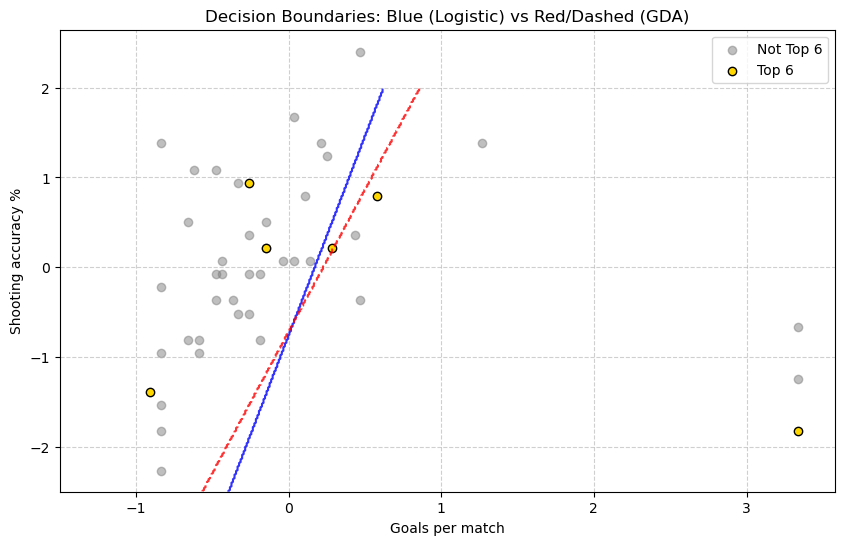

In [357]:
#for forwards 
# Adding .copy() at the end tells Pandas: "Make this a separate DataFrame"
forwards = forwards[forwards['Position'].str.contains('Forward')].copy()
features_f = ['Goals per match', 'Shooting accuracy %', 'Assists', 'Passes per match', 'Big chances created']

X_train_f, X_test_f, y_train_f, y_test_f, my_scale_f = prepare_model_data(forwards, features_f, clubs)
model_log_f = logistic_regression_pipeline(X_train_f, y_train_f, X_test_f, y_test_f)
model_gda_f = GDA(X_train_f, X_test_f, y_train_f, y_test_f, features_f)
plot_decision_boundaries(X_train_f, y_train_f, model_log_f, model_gda_f, features_f)

Test Accuracy: 0.62
Confusion Matrix:
[[40 26]
 [ 2  5]]
    True Positives (TP): Players correctly classified as being in top clubs.
    False Positives (FP): Players incorrectly classified as being in top clubs.
    False Negatives (FN): Players incorrectly classified as not being in top clubs.
    True Negatives (TN): Players correctly classified as not being in top clubs.
Test Accuracy (GDA): 0.89
Confusion Matrix (GDA):
[[63  3]
 [ 5  2]]


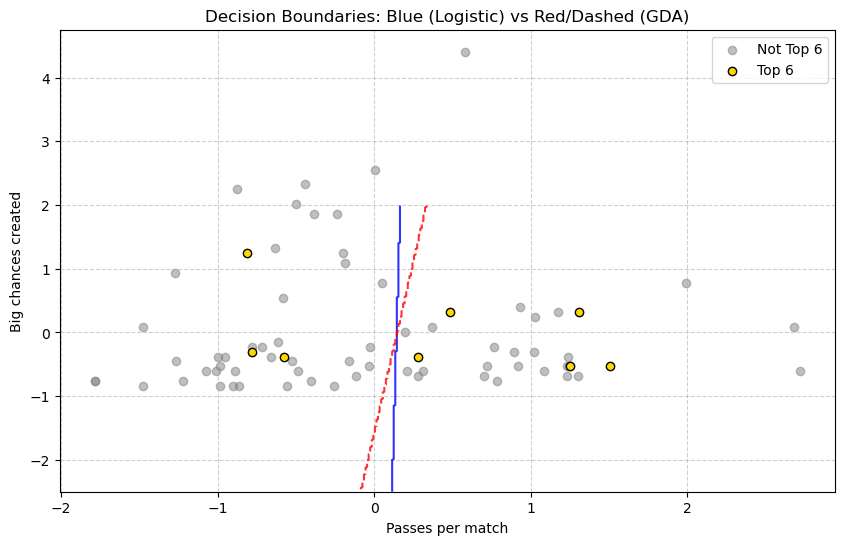

In [358]:
#for midfielders

features_m = ['Passes per match', 'Big chances created', 'Assists', 'Through balls', 'Interceptions', 'Recoveries', 'Tackles', 'Cross accuracy %']
X_train_m, X_test_m, y_train_m, y_test_m, my_scale_m = prepare_model_data(midfielders, features_m, clubs)
model_log_m = logistic_regression_pipeline(X_train_m, y_train_m, X_test_m, y_test_m)
model_gda_m = GDA(X_train_m, X_test_m, y_train_m, y_test_m, features_m)
plot_decision_boundaries(X_train_m, y_train_m, model_log_m, model_gda_m, features_m)


Test Accuracy: 0.86
Confusion Matrix:
[[50  5]
 [ 4  6]]
    True Positives (TP): Players correctly classified as being in top clubs.
    False Positives (FP): Players incorrectly classified as being in top clubs.
    False Negatives (FN): Players incorrectly classified as not being in top clubs.
    True Negatives (TN): Players correctly classified as not being in top clubs.
Test Accuracy (GDA): 0.85
Confusion Matrix (GDA):
[[54  1]
 [ 9  1]]


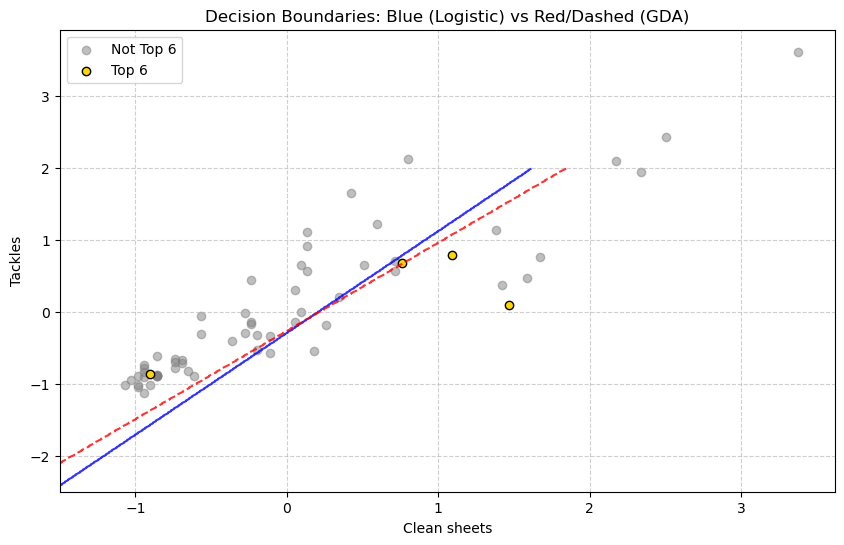

In [359]:
#for defenders
# Adding .copy() at the end tells Pandas: "Make this a separate DataFrame"
defenders = defenders[defenders['Position'].str.contains('Defender')].copy()
features_d = ['Clean sheets', 'Tackles', 'Tackle success %', 'Interceptions', 'Clearances', 'Aerial battles won']
X_train_d, X_test_d, y_train_d, y_test_d, my_scale_d = prepare_model_data(defenders,  features_d, clubs)
model_log_d = logistic_regression_pipeline(X_train_d, y_train_d, X_test_d, y_test_d)
model_gda_d = GDA(X_train_d, X_test_d, y_train_d, y_test_d, features_d)
plot_decision_boundaries(X_train_d, y_train_d, model_log_d, model_gda_d, features_d)


Test Accuracy: 0.53
Confusion Matrix:
[[7 7]
 [1 2]]
    True Positives (TP): Players correctly classified as being in top clubs.
    False Positives (FP): Players incorrectly classified as being in top clubs.
    False Negatives (FN): Players incorrectly classified as not being in top clubs.
    True Negatives (TN): Players correctly classified as not being in top clubs.
Test Accuracy (GDA): 0.82
Confusion Matrix (GDA):
[[12  2]
 [ 1  2]]


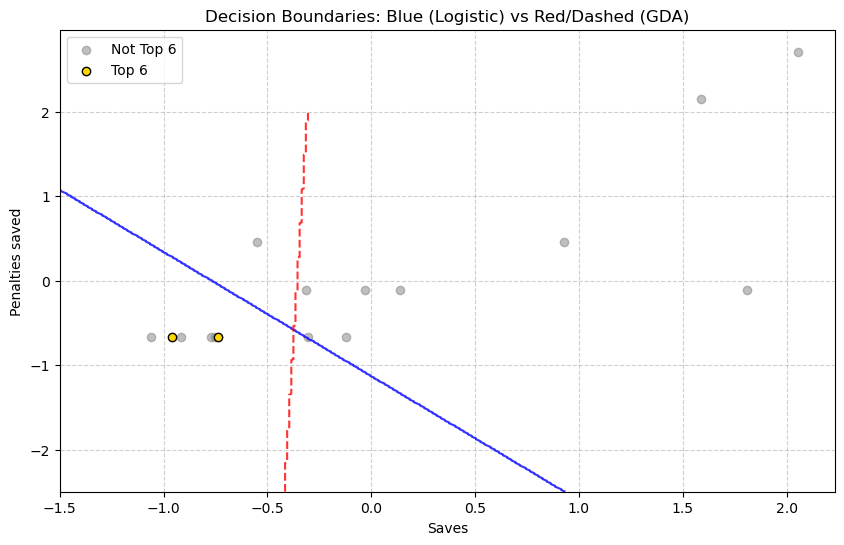

In [360]:
#for goalkeepers
# Adding .copy() at the end tells Pandas: "Make this a separate DataFrame"
goalkeepers = goalkeepers[goalkeepers['Position'].str.contains('Goalkeeper')].copy()
features_gk = ['Saves', 'Penalties saved', 'Clean sheets', 'Goals conceded', 'High Claims', 'Punches', 'Sweeper clearances', 'Goal Kicks'
]
X_train_gk, X_test_gk, y_train_gk, y_test_gk, my_scale_gk = prepare_model_data(goalkeepers, features_gk, clubs)
model_log_gk = logistic_regression_pipeline(X_train_gk, y_train_gk, X_test_gk, y_test_gk)
model_gda_gk = GDA(X_train_gk, X_test_gk, y_train_gk, y_test_gk, features_gk)
plot_decision_boundaries(X_train_gk, y_train_gk, model_log_gk, model_gda_gk, features_gk)

In [363]:
# Test Forwards
print("--- TESTING FORWARDS ---")
print(predict_player_status("Mohamed Salah", forwards, features_f, model_log_f, model_gda_f, my_scale_f))
print(predict_player_status("Sergio Agüero", forwards, features_f, model_log_f, model_gda_f, my_scale_f))
print(predict_player_status("Harry Kane", forwards, features_f, model_log_f, model_gda_f, my_scale_f))

# Test Midfielders
print("\n--- TESTING MIDFIELDERS ---")
print(predict_player_status("Kevin De Bruyne", midfielders, features_m, model_log_m, model_gda_m, my_scale_m))
print(predict_player_status("David Silva", midfielders, features_m, model_log_m, model_gda_m, my_scale_m))

# Test Defenders
print("\n--- TESTING DEFENDERS ---")
print(predict_player_status("Virgil van Dijk", defenders, features_d, model_log_d, model_gda_d, my_scale_d))
print(predict_player_status("Vincent Kompany", defenders, features_d, model_log_d, model_gda_d, my_scale_d))
# عشان تعرف مين المهاجمين اللي عندك وتختار صح
print(forwards['Name'].unique()[:20])

--- TESTING FORWARDS ---

Prediction Report for: Mohamed Salah
-----------------------------------
Logistic Regression : Deserves Top 6 (Confidence: 74.7%)
GDA Model           : Does NOT deserve Top 6
-----------------------------------


Prediction Report for: Sergio Agüero
-----------------------------------
Logistic Regression : Deserves Top 6 (Confidence: 87.7%)
GDA Model           : Deserves Top 6
-----------------------------------


Prediction Report for: Harry Kane
-----------------------------------
Logistic Regression : Deserves Top 6 (Confidence: 71.7%)
GDA Model           : Does NOT deserve Top 6
-----------------------------------


--- TESTING MIDFIELDERS ---

Prediction Report for: Kevin De Bruyne
-----------------------------------
Logistic Regression : Does NOT deserve Top 6 (Confidence: 47.7%)
GDA Model           : Does NOT deserve Top 6
-----------------------------------

Player 'David Silva' not found in this category.

--- TESTING DEFENDERS ---

Prediction Report 